<a href="https://colab.research.google.com/github/SampMark/Machine-Learning/blob/main/Sentiment_Analysis___an_introduction_to_machine_learning_algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Classificação: Análise de Sentimentos/Opiniões de Usuários**

### **Objetivo**
Este laboratório tem por objetivo construir um **sistema de análise de sentimentos/opiniões**, utilizando aprendizado de máquina para classificar avaliações de produtos e/ou serviços como **positivas (+1)** ou **negativas (-1)**. O foco principal é treinar e avaliar diferentes classificadores lineares, analisando sua precisão e capacidade de generalização.

## **✅ O projeto envolve as seguintes etapas**:
1. **Carregamento dos dados**: Importação e processamento do conjunto de dados de avaliações de produtos.
2. **Pré-processamento**: Transformação dos textos em representações numéricas (_Bag-of-Words_), com remoção de palavras irrelevantes (_stopwords_).
3. **Treinamento dos modelos**: Implementação e treinamento de três algoritmos de classificação:
   - **Perceptron**: Algoritmo linear básico.
   - **Perceptron Médio**: Variante que suaviza os pesos ao longo do tempo.
   - **Pegasos**: Um método baseado em *Support Vector Machines (SVM)* com otimização por *Stochastic Gradient Descent*.
4. **Avaliação dos Modelos**: Comparação de desempenho no conjunto de validação e teste.
5. **Otimização de Hiperparâmetros**: Ajuste fino dos parâmetros para obter melhor desempenho.
6. **Visualização de Resultados**: Geração de gráficos para melhor compreensão do comportamento dos modelos.

## **✅ Funcionamento Geral**
O laboratório segue uma **estrutura modular**, organizada em diferentes classes e funções. Isso facilita a manutenção do código e a reutilização das funções para futuras análises.

O _pipeline_ geral é o seguinte:

1. **Montagem do Google Drive** (para carregar os arquivos do dataset).
2. **Carregamento dos dados** a partir de repositório no GitHub usando `DatasetLoader`.
3. **Pré-processamento dos textos** e conversão para vetores numéricos com `Preprocessing`.
4. **Treinamento dos modelos** (Perceptron, Perceptron Médio, Pegasos).
5. **Avaliação dos modelos** em conjunto de validação e teste.
6. **Ajuste de hiperparâmetros** para otimizar os modelos.
7. **Visualização e interpretação dos resultados**.

## **✅ Estrutura do Código**
O código tem uma estrutura **modular** e **orientado a objetos**, com as seguintes classes e funções principais:

### **1. Manipulação dos Dados**
- **Classe `DatasetLoader`**
  - Responsável por carregar os arquivos do dataset.
  - Pode descompactar arquivos ZIP (se necessário).
  - Extrai textos e rótulos das avaliações.

- **Classe `Preprocessing`**
  - Gera representações numéricas (*Bag-of-Words*).
  - Remove *stopwords* (se habilitado).
  - Transforma textos em vetores de features.

### **2. Modelos de Classificação**
- **Classe `BaseClassifier`**
  - Define a estrutura básica para classificadores lineares.
  - Implementa `predict()` e `evaluate()`.

- **Classe `PerceptronClassifier`**
  - Implementa o algoritmo Perceptron padrão.
  - Atualiza os pesos iterativamente com base nos erros.

- **Classe `AveragePerceptronClassifier`**
  - Variante que acumula e usa a média dos pesos ao longo das iterações.

- **Classe `PegasosClassifier`**
  - Implementa o algoritmo Pegasos (*SVM linear com SGD*).
  - Usa regularização para evitar overfitting.

### **3. Treinamento e Avaliação**
- **Classe `ModelTrainer`**
  - Realiza treinamento de modelos.
  - Permite afinar hiperparâmetros (`T` e `L`).
  - Avalia a acurácia nos conjuntos de treino e validação.

### **4. Otimização de Hiperparâmetros**
- **Funções para ajuste de hiperparâmetros**
  - `tune_parameter()`: Busca o melhor valor de `T` e `L`.
  - `plot_tune_results()`: Gera gráficos para visualizar os resultados.

### **5. Visualização de Resultados**
- **Gráficos de desempenho**
  - Acurácia do Perceptron vs Épocas (`T`).
  - Acurácia do Pegasos vs Regularização (`λ`).
  - Comparação entre modelos.

---

Em linhas gerais, este laboratório proporciona uma visão prática de aprendizado de máquina aplicado à análise de sentimentos/opiniões, cobrindo desde a **preparação dos dados** até a **implementação de modelos** e **avaliação de desempenho**.

Com efeito, é possível entender não apenas **como construir um classificador de sentimentos/opiniões**, mas também **como avaliar e melhorar modelos de aprendizado de máquina**.

---


In [1]:
# @title Importação e instalação de bibliotecas
import os
import csv
import sys
import string
import random
import requests
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# Para garantir reprodutibilidade para experimentos
np.random.seed(42)
random.seed(42)

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# @title Download do DataSet disponível no GitHub

urls = {
    "200.txt": "https://raw.githubusercontent.com/SampMark/Sentiment-Analysis/refs/heads/main/200.txt",
    "4000.txt": "https://raw.githubusercontent.com/SampMark/Sentiment-Analysis/refs/heads/main/4000.txt",
    "stopwords.txt": "https://raw.githubusercontent.com/SampMark/Sentiment-Analysis/refs/heads/main/stopwords.txt",
    "reviews_test.tsv": "https://raw.githubusercontent.com/SampMark/Sentiment-Analysis/af8d87fee38cd2844e349d734613822ff9d33a5a/reviews_test.tsv",
    "reviews_train.tsv": "https://raw.githubusercontent.com/SampMark/Sentiment-Analysis/af8d87fee38cd2844e349d734613822ff9d33a5a/reviews_train.tsv",
    "reviews_val.tsv": "https://raw.githubusercontent.com/SampMark/Sentiment-Analysis/af8d87fee38cd2844e349d734613822ff9d33a5a/reviews_val.tsv",
    "toy_data.tsv": "https://raw.githubusercontent.com/SampMark/Sentiment-Analysis/af8d87fee38cd2844e349d734613822ff9d33a5a/toy_data.tsv"
}

for filename, url in urls.items():
    r = requests.get(url)
    with open(filename, 'wb') as f:
        f.write(r.content)
    print(f"Baixado: {filename}")

Baixado: 200.txt
Baixado: 4000.txt
Baixado: stopwords.txt
Baixado: reviews_test.tsv
Baixado: reviews_train.tsv
Baixado: reviews_val.tsv
Baixado: toy_data.tsv


In [5]:
# @title Caminho dos arquivos baixados no Drive
for filename in os.listdir():
    if os.path.isfile(filename):
        print(f"Arquivo: {filename}, Caminho completo: {os.path.abspath(filename)}")

Arquivo: reviews_val.tsv, Caminho completo: /content/reviews_val.tsv
Arquivo: stopwords.txt, Caminho completo: /content/stopwords.txt
Arquivo: 200.txt, Caminho completo: /content/200.txt
Arquivo: reviews_train.tsv, Caminho completo: /content/reviews_train.tsv
Arquivo: 4000.txt, Caminho completo: /content/4000.txt
Arquivo: toy_data.tsv, Caminho completo: /content/toy_data.tsv
Arquivo: reviews_test.tsv, Caminho completo: /content/reviews_test.tsv


# **Classe `DatasetLoader`**

A classe `DatasetLoader` gerencia o carregamento dos arquivos de dados, permitindo:
- **Descompactar** os arquivos que compõem um Dataset (quando for o caso), para um diretório de destino.
- **Ler** os arquivos do tipo TSV de reviews (treino, validação, teste) e extrair as colunas relevantes (texto e rótulo de sentimento).
- Retornar os textos e rótulos prontos para uso.

---



In [6]:
# @title Carregamento do DataSet
class DatasetLoader:
    def __init__(self, base_path='/content', zip_path=None):
        """
        Classe para carregar datasets de análise de sentimentos.
        - base_path: diretório base onde os arquivos TSV estão ou serão extraídos.
        - zip_path: caminho opcional para um arquivo .zip contendo o dataset.
        """
        self.base_path = base_path
        # Se um arquivo zip for fornecido, descompacta no diretório base
        if zip_path:
            self._extract_zip(zip_path, base_path)

    def _extract_zip(self, zip_path, extract_to):
        """Descompacta um arquivo zip para o diretório especificado."""
        import zipfile
        if not os.path.exists(extract_to):
            os.makedirs(extract_to)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print(f"Dataset descompactado em: {extract_to}")

    def load_data(self, filename, extras=False):
        """
        Carrega um arquivo TSV de reviews e retorna uma lista de dicionários
        (ou tuplas de texto e sentimento).
        - filename: nome do arquivo (ou caminho relativo a base_path) a ser carregado.
        - extras: se True, mantém campos extras (como produto, usuário, etc.),
                  se False, carrega apenas texto e sentimento.
        """
        path = os.path.join(self.base_path, filename)
        data = []
        # Define quais campos manter e quais são numéricos
        basic_fields = {'sentiment', 'text'}
        numeric_fields = {'sentiment', 'helpfulY', 'helpfulN'}
        # Abre o arquivo TSV com encoding apropriado
        with open(path, encoding='latin1') as f:
            reader = csv.DictReader(f, delimiter='\t')
            for row in reader:
                if not extras:
                    # Remove campos não básicos se extras=False
                    for field in list(row.keys()):
                        if field not in basic_fields:
                            row.pop(field, None)
                # Converte campos numéricos para int
                for field in numeric_fields:
                    if field in row and row[field] != '':
                        row[field] = int(row[field])
                data.append(row)
        print(f"{len(data)} registros carregados de {filename}.")
        return data

    def load_split(self, split='train'):
        """
        Carrega os dados do conjunto especificado (train, val ou test) e retorna
        duas listas: textos e rótulos.
        """
        file_map = {
            'train': 'reviews_train.tsv',
            'val': 'reviews_val.tsv',
            'test': 'reviews_test.tsv'
        }
        if split not in file_map:
            raise ValueError("Split inválido. Use 'train', 'val' ou 'test'.")
        # Carrega o arquivo correspondente
        data = self.load_data(file_map[split], extras=False)
        # Separa textos e rótulos do sentimento
        texts = [sample['text'] for sample in data]
        labels = [sample['sentiment'] for sample in data]
        return texts, labels

In [8]:
# @title Verificação do carregamento do DataSet para uso...
loader = DatasetLoader(base_path='/content', zip_path=None)
train_texts, train_labels = loader.load_split('train')
val_texts, val_labels = loader.load_split('val')
test_texts, test_labels = loader.load_split('test')

4000 registros carregados de reviews_train.tsv.
500 registros carregados de reviews_val.tsv.
500 registros carregados de reviews_test.tsv.


In [9]:
# @title **Pré-processamento dos Dados**
class Preprocessing:
    def __init__(self, remove_stopwords=True, binarize=True):
        """
        Classe para pré-processar textos em vetores de features.
        - remove_stopwords: se True, remove stopwords do vocabulário.
        - binarize: se True, usa representação binária (presença/ausência de palavra).
        """
        self.remove_stopwords = remove_stopwords
        self.binarize = binarize
        self.stopwords = set()
        self.vocabulary = {}  # mapeamento palavra -> índice
        # Carrega stopwords de arquivo se necessário
        if self.remove_stopwords:
            try:
                with open("stopwords.txt", "r", encoding="utf-8") as f:
                    for line in f:
                        word = line.strip()
                        if word:
                            self.stopwords.add(word)
            except FileNotFoundError:
                print("Aviso: 'stopwords.txt' não encontrado. Processando sem remover stopwords.")

    def _tokenize(self, text):
        """
        Quebra um texto em tokens/palavras, separando pontuação e números como tokens próprios.
        Retorna a lista de palavras em minúsculas.
        """
        # Substitui cada pontuação ou dígito por espaço + símbolo + espaço, para isolar tokens
        for char in string.punctuation + string.digits:
            text = text.replace(char, f" {char} ")
        # Converte para minúsculas e separa por espaços
        tokens = text.lower().split()
        return tokens

    def fit(self, texts):
        """
        Constroi o vocabulário (dicionário de palavra->índice) a partir de uma lista de textos.
        """
        self.vocabulary = {}
        for text in texts:
            words = self._tokenize(text)
            for w in words:
                # Se remove_stopwords estiver habilitado, ignora stopwords
                if self.remove_stopwords and w in self.stopwords:
                    continue
                if w not in self.vocabulary:
                    # Atribui o próximo índice disponível à nova palavra
                    self.vocabulary[w] = len(self.vocabulary)
        print(f"Vocabulário construído com {len(self.vocabulary)} palavras (features).")
        return self.vocabulary

    def transform(self, texts):
        """
        Transforma uma lista de textos em uma matriz de features NumPy utilizando o vocabulário.
        Retorna uma matriz de shape (n_textos, n_features).
        """
        n_texts = len(texts)
        n_features = len(self.vocabulary)
        # Inicializa matriz de zeros
        feature_matrix = np.zeros((n_texts, n_features), dtype=np.float64)
        for i, text in enumerate(texts):
            words = self._tokenize(text)
            for w in words:
                if self.remove_stopwords and w in self.stopwords:
                    continue
                if w in self.vocabulary:
                    j = self.vocabulary[w]  # índice da palavra no vocabulário
                    if self.binarize:
                        feature_matrix[i, j] = 1.0  # Marca presença da palavra
                    else:
                        feature_matrix[i, j] += 1.0  # Conta ocorrências da palavra
        return feature_matrix

In [10]:
# Exemplo de uso:
preproc = Preprocessing(remove_stopwords=True, binarize=True)
vocab = preproc.fit(train_texts)       # constroi dicionário a partir dos textos de treino
X_train = preproc.transform(train_texts)
X_val   = preproc.transform(val_texts)
X_test  = preproc.transform(test_texts)
print("Tamanho de X_train:", X_train.shape)

Vocabulário construído com 13108 palavras (features).
Tamanho de X_train: (4000, 13108)


In [13]:
# @title **Modelos de Classificação**
class BaseClassifier:
    def __init__(self):
        # Inicializa os parâmetros do modelo (serão ajustados no treinamento)
        self.theta = None   # vetor de pesos
        self.theta0 = None  # bias (termo independente)

    def predict(self, X):
        """
        Realiza previsão (+1 ou -1) para cada exemplo em X, usando o modelo treinado.
        """
        if self.theta is None or self.theta0 is None:
            raise Exception("Modelo não treinado. Chame train() antes de predict().")
        # Calcula as pontuações lineares: theta . x + theta0
        scores = X.dot(self.theta) + self.theta0
        # Classifica como +1 se score > 0, caso contrário -1
        # (Aqui, consideramos score=0 como classe -1 por convenção)
        preds = np.where(scores > 0, 1, -1)
        return preds

    def evaluate(self, X, y):
        """
        Calcula a acurácia do modelo (fração de acertos) em relação aos rótulos verdadeiros y.
        """
        preds = self.predict(X)
        # Converte y para array numpy para facilitar comparação
        y_array = np.array(y)
        accuracy = (preds == y_array).mean()
        return accuracy

    def train(self, X, y, **kwargs):
        """
        Método de treinamento (a ser implementado nas subclasses específicas).
        """
        raise NotImplementedError("Este método deve ser implementado na subclasse.")

In [15]:
# @title **Algoritmo Perceptron**
class PerceptronClassifier(BaseClassifier):
    def __init__(self):
        super().__init__()  # inicializa theta e theta0 como None

    def train(self, X, y, T=1):
        """
        Treina o classificador Perceptron.
        - X: matriz de features (n_examples x n_features)
        - y: vetor de rótulos (+1, -1) de tamanho n_examples
        - T: número de épocas (iterações sobre todo o conjunto de treinamento)
        """
        n_samples, n_features = X.shape
        # Inicializa parâmetros
        self.theta = np.zeros(n_features)
        self.theta0 = 0.0
        # Realiza T épocas de treinamento
        for _ in range(T):
            # Embaralha a ordem dos exemplos para cada época (melhora convergência)
            indices = np.random.permutation(n_samples)
            for i in indices:
                x_i = X[i]
                y_i = y[i]
                # Checa se o exemplo está misclassificado (y_i * (theta·x_i + theta0) <= 0)
                if y_i * (np.dot(self.theta, x_i) + self.theta0) <= 0:
                    # Atualiza os parâmetros
                    self.theta += y_i * x_i
                    self.theta0 += y_i
        return self.theta, self.theta0  # retorna os parâmetros aprendidos (opcional)

print("Treinando o Perceptron...")
perceptron = PerceptronClassifier()
perceptron.train(X_train, train_labels, T=10)

Treinando o Perceptron...


(array([  3., -11.,  -4., ...,   1.,   1.,   1.]), -4.0)

In [18]:
# @title **Perceptron Médio (_Average Perceptron_)**

class AveragePerceptronClassifier(BaseClassifier):
    def __init__(self):
        super().__init__()

    def train(self, X, y, T=1):
        """
        Treina o Perceptron Médio por T épocas.
        """
        n_samples, n_features = X.shape
        # Inicializa parâmetros
        self.theta = np.zeros(n_features)
        self.theta0 = 0.0
        # Variáveis para somar os parâmetros em cada atualização
        sum_theta = np.zeros(n_features)
        sum_theta0 = 0.0
        count = 0  # contador de updates (ou de instâncias processadas)
        for _ in range(T):
            indices = np.random.permutation(n_samples)
            for i in indices:
                x_i = X[i]
                y_i = y[i]
                if y_i * (np.dot(self.theta, x_i) + self.theta0) <= 0:
                    # Atualiza (igual ao Perceptron padrão)
                    self.theta += y_i * x_i
                    self.theta0 += y_i
                # Acumula os parâmetros atuais em sum_theta/ sum_theta0
                sum_theta += self.theta
                sum_theta0 += self.theta0
                count += 1
        # Calcula a média dos parâmetros
        if count > 0:
            self.theta = sum_theta / count
            self.theta0 = sum_theta0 / count
        # Retorna os parâmetros médios
        return self.theta, self.theta0

print("Treinando o Perceptron Médio...")
avg_perceptron = AveragePerceptronClassifier()
avg_perceptron.train(X_train, train_labels, T=10)

Treinando o Perceptron Médio...


(array([ 2.640825, -8.288675, -2.47505 , ...,  1.533975,  1.533975,
         1.533975]),
 -0.4136)

In [20]:
# @title **Pegasos (SVM Linear via SGD)**

class PegasosClassifier(BaseClassifier):
    def __init__(self):
        super().__init__()

    def train(self, X, y, T=1, L=0.01):
        """
        Treina o classificador Pegasos (SVM linear) por T épocas.
        - T: número de épocas (passadas completas pelos dados)
        - L: lambda de regularização (parâmetro do Pegasos)
        """
        n_samples, n_features = X.shape
        # Inicializa parâmetros
        self.theta = np.zeros(n_features)
        self.theta0 = 0.0
        # Contador de iterações para calcular eta
        t = 1
        for _ in range(T):
            indices = np.random.permutation(n_samples)
            for i in indices:
                x_i = X[i]
                y_i = y[i]
                # Calcula a margem
                margin = y_i * (np.dot(self.theta, x_i) + self.theta0)
                # Calcula taxa de aprendizado para esta iteração
                eta = 1.0 / np.sqrt(t)
                if margin <= 1:
                    # Violou margem: atualiza theta e theta0 com gradiente de hinge loss
                    self.theta = (1 - eta * L) * self.theta + eta * y_i * x_i
                    self.theta0 += eta * y_i
                else:
                    # Não violou margem: só aplica regularização (decaimento)
                    self.theta = (1 - eta * L) * self.theta
                    # theta0 não muda
                t += 1
        return self.theta, self.theta0
print("Treinando o Pegasos...")
pegasos = PegasosClassifier()
pegasos.train(X_train, train_labels, T=10, L=0.01)

Treinando o Pegasos...


(array([ 0.02999411, -0.26543663, -0.02150188, ...,  0.02419352,
         0.02419352,  0.02419352]),
 0.036655683474547514)

In [22]:
# @title **Treinamento e Avaliação**
# Configuração dos dados
loader = DatasetLoader(base_path='/content', zip_path=None)
train_texts, train_labels = loader.load_split('train')
val_texts, val_labels = loader.load_split('val')
test_texts, test_labels = loader.load_split('test')

preproc = Preprocessing(remove_stopwords=True, binarize=True)
preproc.fit(train_texts)
X_train = preproc.transform(train_texts)
X_val   = preproc.transform(val_texts)
X_test  = preproc.transform(test_texts)

4000 registros carregados de reviews_train.tsv.
500 registros carregados de reviews_val.tsv.
500 registros carregados de reviews_test.tsv.
Vocabulário construído com 13108 palavras (features).


In [23]:
# @title **Treinando os modelos com um hiperparâmetro base**
# Instancia os classificadores
perc = PerceptronClassifier()
avg_perc = AveragePerceptronClassifier()
peg = PegasosClassifier()

# Treina cada modelo com hiperparâmetros iniciais
perc.train(X_train, train_labels, T=10)
avg_perc.train(X_train, train_labels, T=10)
peg.train(X_train, train_labels, T=10, L=0.01)

# Avalia acurácia em treino e validação para cada modelo
print(f"Perceptron - Acurácia treino: {perc.evaluate(X_train, train_labels)*100:.2f}%, validação: {perc.evaluate(X_val, val_labels)*100:.2f}%")
print(f"Perceptron Médio - Acurácia treino: {avg_perc.evaluate(X_train, train_labels)*100:.2f}%, validação: {avg_perc.evaluate(X_val, val_labels)*100:.2f}%")
print(f"Pegasos - Acurácia treino: {peg.evaluate(X_train, train_labels)*100:.2f}%, validação: {peg.evaluate(X_val, val_labels)*100:.2f}%")


Perceptron - Acurácia treino: 98.92%, validação: 76.20%
Perceptron Médio - Acurácia treino: 98.95%, validação: 76.40%
Pegasos - Acurácia treino: 91.17%, validação: 79.00%


In [40]:
# @title **Otimização de Hiperparâmetros**

class ModelTrainer:
    def __init__(self):
        pass  # nenhuma propriedade fixa necessária

    def tune_parameter(self, ModelClass, param_name, param_values, X_train, y_train, X_val, y_val, **kwargs):
        """
        Testa diferentes valores de um hiperparâmetro para um dado modelo e retorna o melhor.
        - ModelClass: a classe do modelo (PerceptronClassifier, etc.)
        - param_name: nome do parâmetro a tunar (string exatamente como o nome do argumento em train())
        - param_values: lista de valores a experimentar
        - X_train, y_train: dados de treinamento
        - X_val, y_val: dados de validação
        - kwargs: outros hiperparâmetros fixos a manter (ex: fixar L enquanto varia T, ou vice-versa)

        Retorna: uma tupla (best_value, train_accuracies, val_accuracies)
        """
        best_value = None
        best_val_acc = -1
        train_acc_list = []
        val_acc_list = []
        for val in param_values:
            # Instancia um novo modelo para cada valor testado (começa "do zero")
            model = ModelClass()
            # Prepara os argumentos de treinamento: combinando o param sendo tunado com outros fixos
            train_args = {**kwargs}
            train_args[param_name] = val
            # Treina o modelo
            model.train(X_train, y_train, **train_args)
            # Avalia no treino e validação
            train_acc = model.evaluate(X_train, y_train)
            val_acc = model.evaluate(X_val, y_val)
            train_acc_list.append(train_acc)
            val_acc_list.append(val_acc)
            # Verifica se é o melhor até agora
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_value = val
        # Converte listas de acurácias para numpy arrays para fácil manipulação (opcional)
        train_acc_list = np.array(train_acc_list)
        val_acc_list = np.array(val_acc_list)
        print(f"Tuning {param_name}: valores testados = {param_values}")
        print(f"Acurácias de validação = {[f'{acc*100:.4f}%' for acc in val_acc_list]}")
        print(f"Melhor {param_name} = {best_value} com acurácia de validação = {best_val_acc*100:.4f}%")
        return best_value, train_acc_list, val_acc_list

In [41]:
# @title **Utilização da Classe `ModelTrainer` para encontrar os melhores hiperparâmetros**

trainer = ModelTrainer()

# Definindo grades de valores para testar
Ts = [1, 5, 10, 15, 25, 50]         # candidatos para número de épocas
Ls = [0.001, 0.01, 0.1, 1, 10]      # candidatos para lambda Pegasos

# Tuning do Perceptron (T)
best_T_perc, perc_train_acc, perc_val_acc = trainer.tune_parameter(
    PerceptronClassifier, 'T', Ts, X_train, train_labels, X_val, val_labels
)

# Tuning do Perceptron Médio (T)
best_T_avg, avg_train_acc, avg_val_acc = trainer.tune_parameter(
    AveragePerceptronClassifier, 'T', Ts, X_train, train_labels, X_val, val_labels
)

# Tuning do Pegasos:
# Primeiro tunar T com lambda fixo (e.g., 0.01)
fixed_L = 0.01
best_T_peg, peg_train_acc_T, peg_val_acc_T = trainer.tune_parameter(
    PegasosClassifier, 'T', Ts, X_train, train_labels, X_val, val_labels, L=fixed_L
)
# Agora tunar lambda L com T fixo no melhor valor obtido
best_L_peg, peg_train_acc_L, peg_val_acc_L = trainer.tune_parameter(
    PegasosClassifier, 'L', Ls, X_train, train_labels, X_val, val_labels, T=best_T_peg
)

Tuning T: valores testados = [1, 5, 10, 15, 25, 50]
Acurácias de validação = ['72.0000%', '74.0000%', '76.8000%', '76.8000%', '76.6000%', '76.0000%']
Melhor T = 10 com acurácia de validação = 76.8000%
Tuning T: valores testados = [1, 5, 10, 15, 25, 50]
Acurácias de validação = ['75.0000%', '76.4000%', '79.8000%', '76.4000%', '77.0000%', '73.8000%']
Melhor T = 10 com acurácia de validação = 79.8000%
Tuning T: valores testados = [1, 5, 10, 15, 25, 50]
Acurácias de validação = ['76.0000%', '79.8000%', '79.4000%', '79.4000%', '79.6000%', '79.2000%']
Melhor T = 5 com acurácia de validação = 79.8000%
Tuning L: valores testados = [0.001, 0.01, 0.1, 1, 10]
Acurácias de validação = ['78.4000%', '78.8000%', '71.4000%', '51.8000%', '51.8000%']
Melhor L = 0.01 com acurácia de validação = 78.8000%


In [42]:
# @title **Avaliação no Conjunto de Teste**

# Escolhe o modelo final - vamos usar Pegasos com hiperparâmetros otimizados neste exemplo
final_model = PegasosClassifier()
final_model.train(X_train, train_labels, T=best_T_peg, L=best_L_peg)
test_accuracy = final_model.evaluate(X_test, test_labels)
print(f"Acurácia no conjunto de TESTE com Pegasos (T={best_T_peg}, λ={best_L_peg}): {test_accuracy*100:.4f}%")

Acurácia no conjunto de TESTE com Pegasos (T=5, λ=0.01): 80.0000%


# **Visualização dos Resultados**

Agora, vamos **visualizar graficamente** os resultados dos experimentos de hiperparâmetro que fizemos, para nos ajudar na interpretação do comportamento dos modelos e a justificar a escolha dos hiperparâmetros.

A seguir, serão gerados um gráfico para cada caso, mostrando a curva de acurácia de **treinamento** e **validação** em função do hiperparâmetro. Desta forma, é possível analisar claramente as tendências de _overfitting_ ou _underfitting_.

1. **Perceptron:** Acurácia vs Número de Épocas (T).
2. **Perceptron Médio:** Acurácia vs Número de Épocas (T).
3. **Pegasos:** Acurácia vs Número de Épocas (T) com λ fixo (no valor inicial usado, ex: 0.01).
4. **Pegasos:** Acurácia vs Lambda (λ) com T fixo (no melhor valor encontrado de T).

---

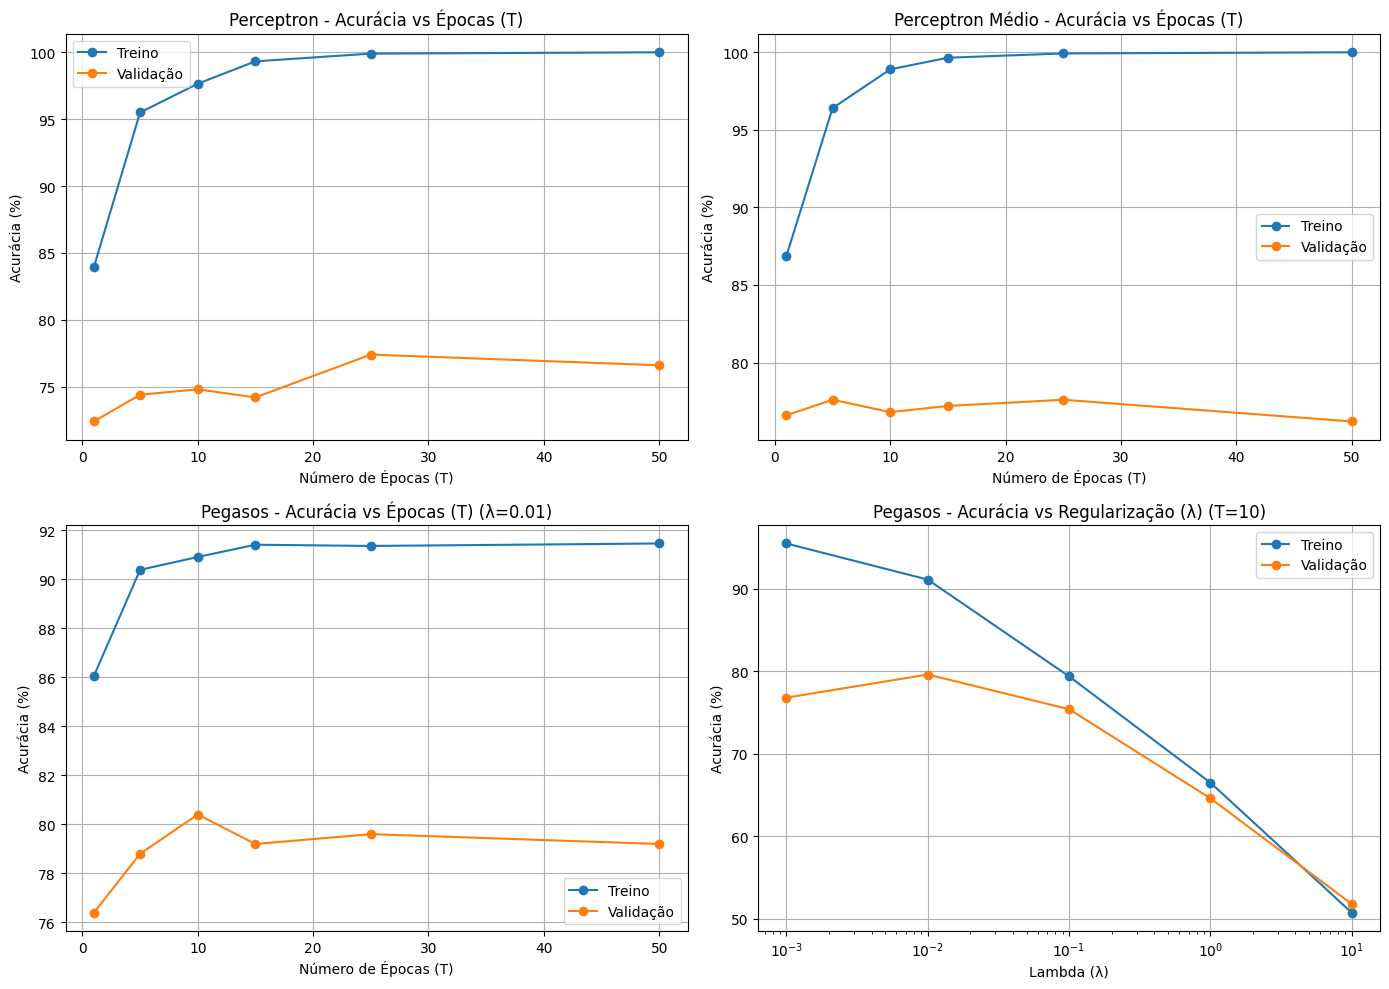

In [33]:
# @title **Plotando os modelos num grid 2x2**
plt.figure(figsize=(14, 10))  # Tamanho total da figura

# 1. Perceptron: Acurácia vs T
plt.subplot(2, 2, 1)  # Posição 1 no grid 2x2
plt.plot(Ts, perc_train_acc * 100, 'o-', label='Treino')
plt.plot(Ts, perc_val_acc * 100, 'o-', label='Validação')
plt.title('Perceptron - Acurácia vs Épocas (T)')
plt.xlabel('Número de Épocas (T)')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)

# 2. Perceptron Médio: Acurácia vs T
plt.subplot(2, 2, 2)  # Posição 2 no grid 2x2
plt.plot(Ts, avg_train_acc * 100, 'o-', label='Treino')
plt.plot(Ts, avg_val_acc * 100, 'o-', label='Validação')
plt.title('Perceptron Médio - Acurácia vs Épocas (T)')
plt.xlabel('Número de Épocas (T)')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)

# 3. Pegasos: Acurácia vs T (λ fixo = 0.01)
plt.subplot(2, 2, 3)  # Posição 3 no grid 2x2
plt.plot(Ts, peg_train_acc_T * 100, 'o-', label='Treino')
plt.plot(Ts, peg_val_acc_T * 100, 'o-', label='Validação')
plt.title(f'Pegasos - Acurácia vs Épocas (T) (λ={fixed_L})')
plt.xlabel('Número de Épocas (T)')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)

# 4. Pegasos: Acurácia vs Lambda (T fixo = {best_T_peg})
plt.subplot(2, 2, 4)  # Posição 4 no grid 2x2
plt.plot(Ls, peg_train_acc_L * 100, 'o-', label='Treino')
plt.plot(Ls, peg_val_acc_L * 100, 'o-', label='Validação')
plt.title(f'Pegasos - Acurácia vs Regularização (λ) (T={best_T_peg})')
plt.xlabel('Lambda (λ)')
plt.ylabel('Acurácia (%)')
plt.xscale('log')  # Escala logarítmica para visualizar melhor a variação de λ
plt.legend()
plt.grid(True)

# Ajustar layout para evitar sobreposição
plt.tight_layout()

# Exibir a figura com todos os gráficos
plt.show()

## **Visualização dos Gráficos Separadamente**

---



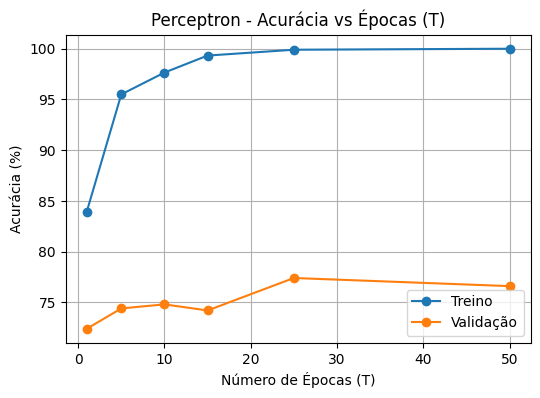

In [34]:
# 1. Perceptron: Acurácia vs T
plt.figure(figsize=(6,4))
plt.plot(Ts, perc_train_acc*100, 'o-', label='Treino')
plt.plot(Ts, perc_val_acc*100, 'o-', label='Validação')
plt.title('Perceptron - Acurácia vs Épocas (T)')
plt.xlabel('Número de Épocas (T)')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)
plt.show()

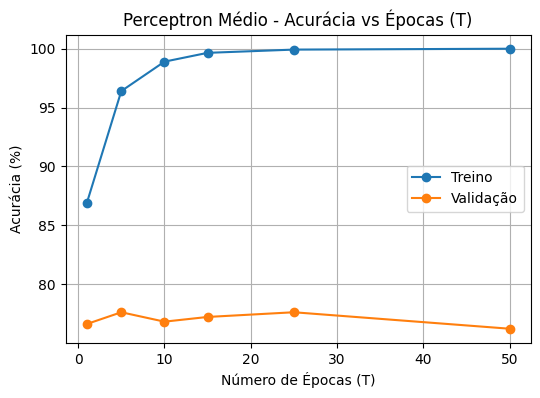

In [35]:
# 2. Perceptron Médio: Acurácia vs T
plt.figure(figsize=(6,4))
plt.plot(Ts, avg_train_acc*100, 'o-', label='Treino')
plt.plot(Ts, avg_val_acc*100, 'o-', label='Validação')
plt.title('Perceptron Médio - Acurácia vs Épocas (T)')
plt.xlabel('Número de Épocas (T)')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)
plt.show()

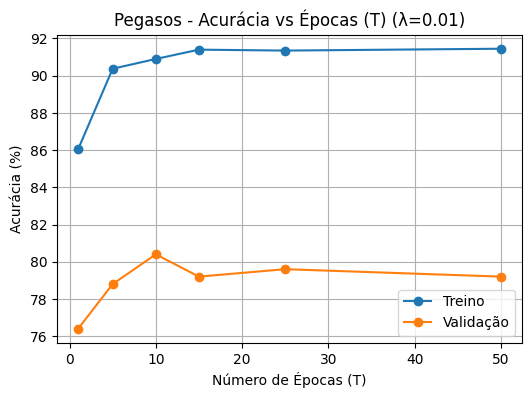

In [36]:
# 3. Pegasos: Acurácia vs T (λ fixo = 0.01)
plt.figure(figsize=(6,4))
plt.plot(Ts, peg_train_acc_T*100, 'o-', label='Treino')
plt.plot(Ts, peg_val_acc_T*100, 'o-', label='Validação')
plt.title(f'Pegasos - Acurácia vs Épocas (T) (λ={fixed_L})')
plt.xlabel('Número de Épocas (T)')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)
plt.show()

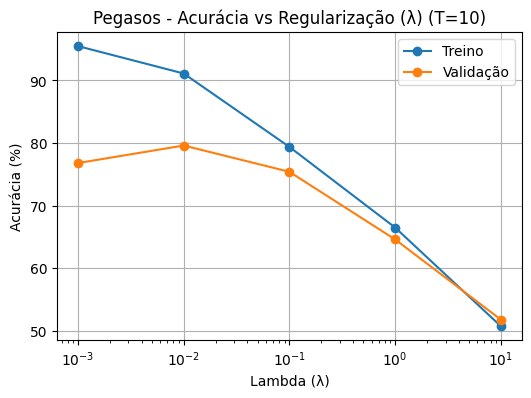

In [37]:
# 4. Pegasos: Acurácia vs Lambda (T fixo = {best_T_peg})
plt.figure(figsize=(6,4))
plt.plot(Ls, peg_train_acc_L*100, 'o-', label='Treino')
plt.plot(Ls, peg_val_acc_L*100, 'o-', label='Validação')
plt.title(f'Pegasos - Acurácia vs Regularização (λ) (T={best_T_peg})')
plt.xlabel('Lambda (λ)')
plt.ylabel('Acurácia (%)')
plt.xscale('log')  # escala logarítmica para visualizar melhor a variação de λ
plt.legend()
plt.grid(True)
plt.show()
